# Machine Learning Model Training and Evaluation

This stage trains and evaluates machine learning models for detecting cyber threats within the simulated maritime network environment.

The flow-level dataset generated during feature engineering is used as input. Both binary and multiclass classification tasks are evaluated to assess the ability of the models to detect malicious activity and distinguish between attack types.

## Import Required Libraries

The following libraries are used for model training, dataset splitting, balancing and evaluation.

In [1]:
# Data manipulation
import pandas as pd
import numpy as np

# Machine learning models
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC

# Dataset splitting
from sklearn.model_selection import train_test_split

# Evaluation metrics
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# Plotting
import matplotlib.pyplot as plt
import seaborn as sns

# Standardise features
from sklearn.preprocessing import StandardScaler

# Handle class imbalance
from imblearn.over_sampling import SMOTE

# Library used to save and load trained machine learning models
import joblib

# Import SHAP library for explainable AI
import shap

## Load Flow Dataset

The flow-level dataset produced during feature engineering is loaded for machine learning analysis.

In [2]:
# Load flow dataset
df = pd.read_csv("../data/processed/flows_v3.csv")

print(df.shape)

df.head()

(369, 12)


,flow_id,packet_count,total_bytes,avg_packet_size,flow_duration,interarrival_mean,interarrival_std,packet_rate,packet_count_log,packet_rate_log,binary_label,multi_label
0,192.168.56.10_192.168.56.15_35318_5005_177414451,2,327,163.500000,1.481448,7.437044,8.422485,1.350031,1.098612,0.854428,0,0
1,192.168.56.10_192.168.56.15_35318_5005_177414452,6,1005,167.500000,8.954694,1.752229,0.264699,0.670040,1.945910,0.512847,0,0
2,192.168.56.10_192.168.56.15_35318_5005_177414453,6,1004,167.333333,7.954704,1.694258,0.555134,0.754271,1.945910,0.562053,0,0
3,192.168.56.10_192.168.56.15_35318_5005_177414454,6,1005,167.500000,8.264359,1.612960,0.418324,0.726009,1.945910,0.545812,0,0
4,192.168.56.10_192.168.56.15_35318_5005_177414455,6,1058,176.333333,8.157557,1.676504,0.543603,0.735514,1.945910,0.551304,0,0


## Define Feature Set

Behavioural flow features are selected as input variables for the machine learning models. Label columns are excluded from the feature set.

In [3]:
# Define features used for ML models
features = [
    "packet_count",
    "total_bytes",
    "avg_packet_size",
    "flow_duration",
    "interarrival_mean",
    "interarrival_std",
    "packet_rate",
    "packet_rate_log",
    "packet_count_log"
]

# Feature matrix
X = df[features]

## Binary Classification Setup

The binary classification task aims to distinguish between normal network traffic and malicious traffic generated by the attacker node.

Binary labels:
- 0 = Normal Traffic
- 1 = Attack Traffic

In [4]:
# Target variable
y_binary = df["binary_label"]

# Split dataset
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y_binary,
    test_size=0.3,
    random_state=42,
    stratify=y_binary
)

### SMOTE Oversampling (Binary)

In [5]:
smote = SMOTE(random_state=42)

# Apply SMOTE ONLY on training data
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

print("Before SMOTE:")
print(y_train.value_counts())

print("\nAfter SMOTE:")
print(pd.Series(y_train_smote).value_counts())

Before SMOTE:
binary_label
0    159
1     99
Name: count, dtype: int64

After SMOTE:
binary_label
0    159
1    159
Name: count, dtype: int64


### Random Forest (Binary)

Random Forest is an ensemble learning algorithm that constructs multiple decision trees and aggregates their predictions to improve classification accuracy.

#### Without SMOTE

In [6]:
# Train Random Forest on original dataset
rf_model = RandomForestClassifier(random_state=42)

rf_model.fit(X_train, y_train)

rf_pred = rf_model.predict(X_test)

print("Random Forest Binary (No SMOTE)\n")
print(classification_report(y_test, rf_pred))

Random Forest Binary (No SMOTE)

              precision    recall  f1-score   support

           0       0.88      0.94      0.91        68
           1       0.89      0.79      0.84        43

    accuracy                           0.88       111
   macro avg       0.89      0.87      0.87       111
weighted avg       0.88      0.88      0.88       111



#### With SMOTE

In [7]:
# Train Random Forest on SMOTE-balanced dataset
rf_model_smote = RandomForestClassifier(random_state=42)

rf_model_smote.fit(X_train_smote, y_train_smote)

rf_pred_smote = rf_model_smote.predict(X_test)

print("Random Forest Binary (SMOTE)\n")
print(classification_report(y_test, rf_pred_smote))

Random Forest Binary (SMOTE)

              precision    recall  f1-score   support

           0       0.89      0.91      0.90        68
           1       0.85      0.81      0.83        43

    accuracy                           0.87       111
   macro avg       0.87      0.86      0.87       111
weighted avg       0.87      0.87      0.87       111



#### RF Binary Confusion Matrix
The confusion matrix illustrates how frequently each traffic class is correctly or incorrectly predicted by the model.

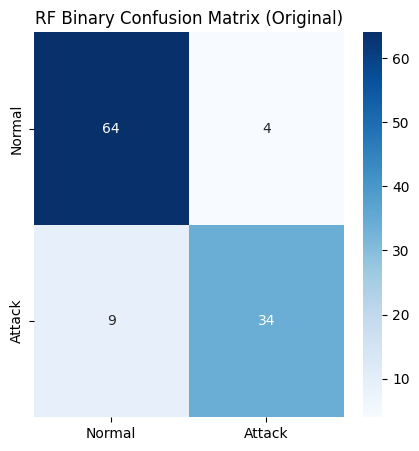

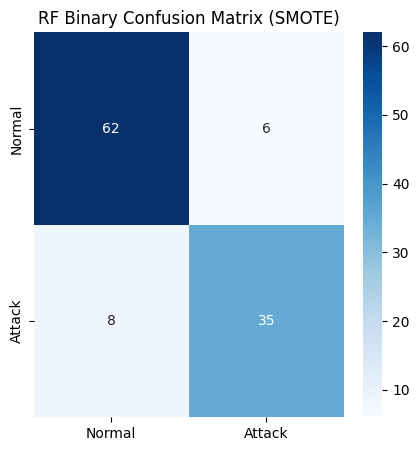

In [8]:
# Original
cm_rf = confusion_matrix(y_test, rf_pred)

plt.figure(figsize=(5,5))
sns.heatmap(cm_rf, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Normal","Attack"],
            yticklabels=["Normal","Attack"])
plt.title("RF Binary Confusion Matrix (Original)")
plt.savefig("../results/confusion_matrices/rf_binary_original.png", dpi=300)
plt.show()


# SMOTE
cm_rf_smote = confusion_matrix(y_test, rf_pred_smote)

plt.figure(figsize=(5,5))
sns.heatmap(cm_rf_smote, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Normal","Attack"],
            yticklabels=["Normal","Attack"])
plt.title("RF Binary Confusion Matrix (SMOTE)")
plt.savefig("../results/confusion_matrices/rf_binary_smote.png", dpi=300)
plt.show()

### Support Vector Machine (Binary)

Support Vector Machines attempt to find an optimal decision boundary that separates classes within the feature space.

#### Feature Scaling for Support Vector Machine

Support Vector Machines are sensitive to the scale of input features. 
Therefore, standardisation is applied so that each feature has zero mean and unit variance before training the SVM model.

In [9]:
# Scale original data
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Scale SMOTE data
scaler_smote = StandardScaler()
X_train_smote_scaled = scaler_smote.fit_transform(X_train_smote)
X_test_scaled_smote = scaler_smote.transform(X_test)

#### Without SMOTE

In [10]:
svm_model = SVC()

svm_model.fit(X_train_scaled, y_train)

svm_pred = svm_model.predict(X_test_scaled)

print("SVM Binary (No SMOTE)\n")
print(classification_report(y_test, svm_pred))

SVM Binary (No SMOTE)

              precision    recall  f1-score   support

           0       0.72      1.00      0.83        68
           1       1.00      0.37      0.54        43

    accuracy                           0.76       111
   macro avg       0.86      0.69      0.69       111
weighted avg       0.83      0.76      0.72       111



#### With SMOTE

In [11]:
svm_model_smote = SVC()

svm_model_smote.fit(X_train_smote_scaled, y_train_smote)

svm_pred_smote = svm_model_smote.predict(X_test_scaled_smote)

print("SVM Binary (SMOTE)\n")
print(classification_report(y_test, svm_pred_smote))

SVM Binary (SMOTE)

              precision    recall  f1-score   support

           0       0.79      1.00      0.88        68
           1       1.00      0.58      0.74        43

    accuracy                           0.84       111
   macro avg       0.90      0.79      0.81       111
weighted avg       0.87      0.84      0.83       111



#### SVM Binary Confusion Matrix


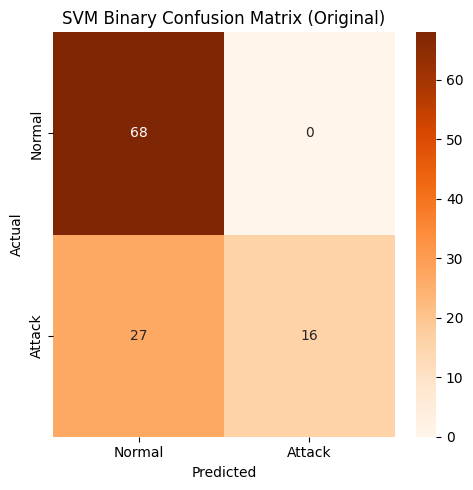

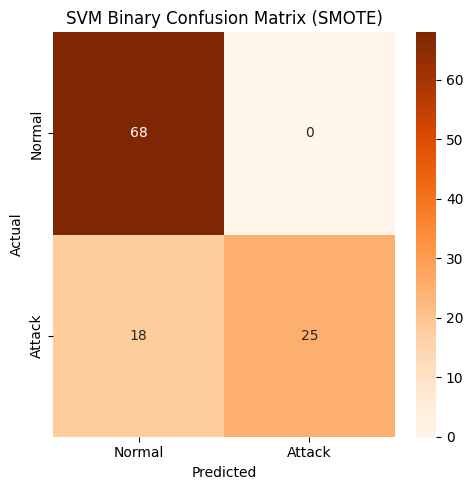

In [12]:
#Original
cm_svm = confusion_matrix(y_test, svm_pred)

plt.figure(figsize=(5,5))

sns.heatmap(
    cm_svm,
    annot=True,
    fmt="d",
    cmap="Oranges",
    xticklabels=["Normal","Attack"],
    yticklabels=["Normal","Attack"]
)

plt.title("SVM Binary Confusion Matrix (Original)")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.tight_layout()

# Save figure
plt.savefig("../results/confusion_matrices/svm_binary_original.png", dpi=300)

plt.show()

#SMOTE
cm_svm_smote = confusion_matrix(y_test, svm_pred_smote)

plt.figure(figsize=(5,5))

sns.heatmap(
    cm_svm_smote,
    annot=True,
    fmt="d",
    cmap="Oranges",
    xticklabels=["Normal","Attack"],
    yticklabels=["Normal","Attack"]
)

plt.title("SVM Binary Confusion Matrix (SMOTE)")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.tight_layout()

# Save figure
plt.savefig("../results/confusion_matrices/svm_binary_smote.png", dpi=300)

plt.show()

## Multiclass Classification Setup

In addition to binary attack detection, a multiclass classification task is performed to determine whether machine learning models can distinguish between different attack types.

The classification labels are defined as:

0 – Normal traffic  
1 – Spoofed navigation attack  
2 – Irregular timing attack  
3 – Burst flooding attack

### Train-Test Split

The dataset is divided into training and testing subsets using stratified sampling. 
This ensures that the distribution of attack classes is preserved in both the training and testing datasets.

In [13]:
y_multi = df["multi_label"]

X_train_m, X_test_m, y_train_m, y_test_m = train_test_split(
    X,
    y_multi,
    test_size=0.3,
    random_state=42,
    stratify=y_multi
)

### SMOTE Oversampling (Multiclass)

In [14]:
smote_multi = SMOTE(random_state=42)

# Apply SMOTE ONLY to training data
X_train_m_smote, y_train_m_smote = smote_multi.fit_resample(X_train_m, y_train_m)

print("Before SMOTE:")
print(y_train_m.value_counts())

print("\nAfter SMOTE:")
print(pd.Series(y_train_m_smote).value_counts())

Before SMOTE:
multi_label
0    159
2     36
1     35
3     28
Name: count, dtype: int64

After SMOTE:
multi_label
3    159
2    159
1    159
0    159
Name: count, dtype: int64


### Random Forest (Multiclass)

Random Forest is trained to classify flows into one of the four traffic categories. 
The model learns behavioural patterns within the flow features to distinguish between attack types.

#### Without SMOTE

In [15]:
# Initialize Random Forest model
rf_multi = RandomForestClassifier(random_state=42)

# Train model on original dataset
rf_multi.fit(X_train_m, y_train_m)

# Predictions
rf_multi_pred = rf_multi.predict(X_test_m)

print("Random Forest Multiclass (No SMOTE)\n")
print(classification_report(y_test_m, rf_multi_pred))

Random Forest Multiclass (No SMOTE)

              precision    recall  f1-score   support

           0       0.83      0.96      0.89        68
           1       0.75      0.38      0.50        16
           2       0.92      0.80      0.86        15
           3       1.00      1.00      1.00        12

    accuracy                           0.86       111
   macro avg       0.88      0.78      0.81       111
weighted avg       0.85      0.86      0.84       111



#### With SMOTE

In [16]:
# Initialize Random Forest model for SMOTE
rf_multi_smote = RandomForestClassifier(random_state=42)

# Train on SMOTE-balanced data
rf_multi_smote.fit(X_train_m_smote, y_train_m_smote)

# Predictions
rf_multi_pred_smote = rf_multi_smote.predict(X_test_m)

print("Random Forest Multiclass (SMOTE)\n")
print(classification_report(y_test_m, rf_multi_pred_smote))

Random Forest Multiclass (SMOTE)

              precision    recall  f1-score   support

           0       0.88      0.93      0.90        68
           1       0.62      0.62      0.62        16
           2       0.91      0.67      0.77        15
           3       1.00      1.00      1.00        12

    accuracy                           0.86       111
   macro avg       0.85      0.80      0.82       111
weighted avg       0.86      0.86      0.85       111



#### RF Multiclass Confusion Matrix

The confusion matrix illustrates how frequently each traffic class is correctly or incorrectly predicted by the model.

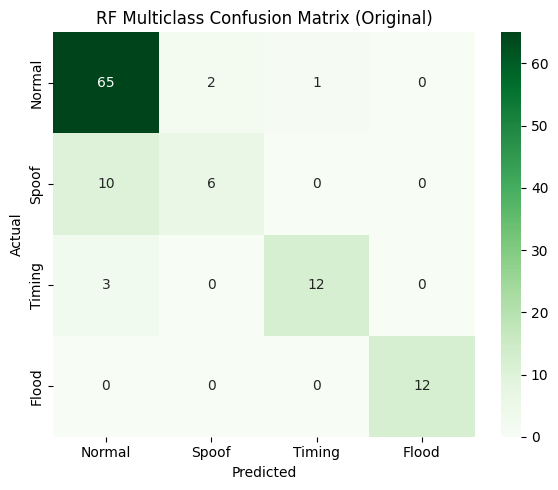

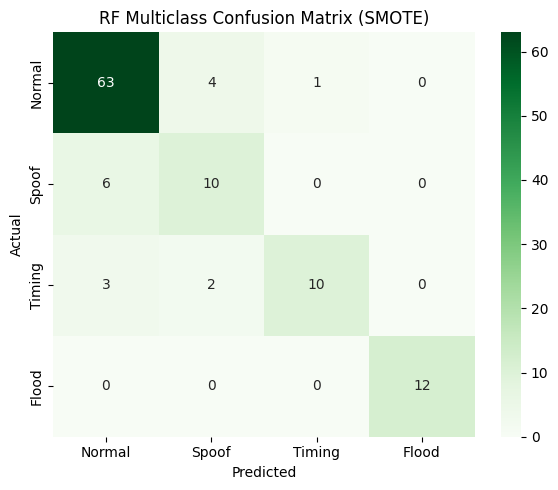

In [17]:
# Class labels for readability
labels = ["Normal", "Spoof", "Timing", "Flood"]

# Original
cm_rf_multi = confusion_matrix(y_test_m, rf_multi_pred)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm_rf_multi,
    annot=True,
    fmt="d",
    cmap="Greens",
    xticklabels=labels,
    yticklabels=labels
)

plt.title("RF Multiclass Confusion Matrix (Original)")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.tight_layout()

# Save figure
plt.savefig("../results/confusion_matrices/rf_multiclass_original.png", dpi=300)

plt.show()

#SMOTE
cm_rf_multi_smote = confusion_matrix(y_test_m, rf_multi_pred_smote)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm_rf_multi_smote,
    annot=True,
    fmt="d",
    cmap="Greens",
    xticklabels=labels,
    yticklabels=labels
)

plt.title("RF Multiclass Confusion Matrix (SMOTE)")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.tight_layout()

# Save figure
plt.savefig("../results/confusion_matrices/rf_multiclass_smote.png", dpi=300)

plt.show()

### Support Vector Machine (Multiclass)

Support Vector Machines are trained using scaled feature values to ensure that all features contribute equally to the decision boundary.

#### Feature Scaling for SVM (Multiclass)

Support Vector Machines are sensitive to the scale of input features. 
Therefore, standardisation is applied so that each feature has zero mean and unit variance before training the SVM model.

In [18]:
# Original data scaling
scaler_m = StandardScaler()
X_train_m_scaled = scaler_m.fit_transform(X_train_m)
X_test_m_scaled = scaler_m.transform(X_test_m)

# SMOTE data scaling
scaler_m_smote = StandardScaler()
X_train_m_smote_scaled = scaler_m_smote.fit_transform(X_train_m_smote)
X_test_m_scaled_smote = scaler_m_smote.transform(X_test_m)

#### Without SMOTE

In [19]:
# Initialize SVM
svm_multi = SVC()

# Train on original scaled data
svm_multi.fit(X_train_m_scaled, y_train_m)

# Predictions
svm_multi_pred = svm_multi.predict(X_test_m_scaled)

print("SVM Multiclass (No SMOTE)\n")
print(classification_report(y_test_m, svm_multi_pred, zero_division=0))

SVM Multiclass (No SMOTE)

              precision    recall  f1-score   support

           0       0.73      0.99      0.84        68
           1       0.00      0.00      0.00        16
           2       0.86      0.40      0.55        15
           3       1.00      1.00      1.00        12

    accuracy                           0.77       111
   macro avg       0.65      0.60      0.60       111
weighted avg       0.67      0.77      0.69       111



#### With SMOTE

In [20]:
# Initialize SVM
svm_multi_smote = SVC()

# Train on SMOTE-scaled data
svm_multi_smote.fit(X_train_m_smote_scaled, y_train_m_smote)

# Predictions
svm_multi_pred_smote = svm_multi_smote.predict(X_test_m_scaled_smote)

print("SVM Multiclass (SMOTE)\n")
print(classification_report(y_test_m, svm_multi_pred_smote, zero_division=0))

SVM Multiclass (SMOTE)

              precision    recall  f1-score   support

           0       0.83      0.59      0.69        68
           1       0.31      0.81      0.45        16
           2       0.89      0.53      0.67        15
           3       1.00      1.00      1.00        12

    accuracy                           0.66       111
   macro avg       0.76      0.73      0.70       111
weighted avg       0.78      0.66      0.69       111



#### SVM Multiclass Confusion Matrix
The confusion matrix illustrates how frequently each traffic class is correctly or incorrectly predicted by the model.

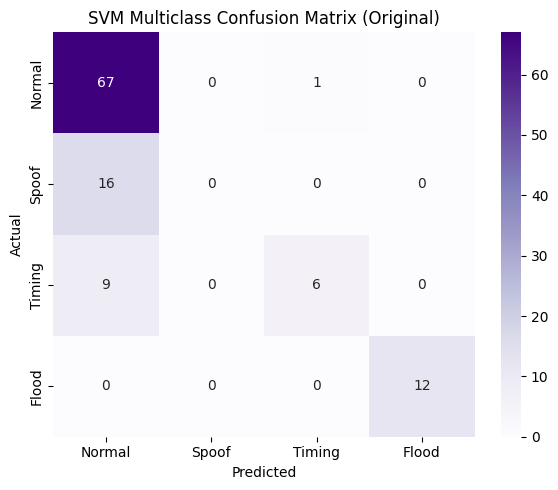

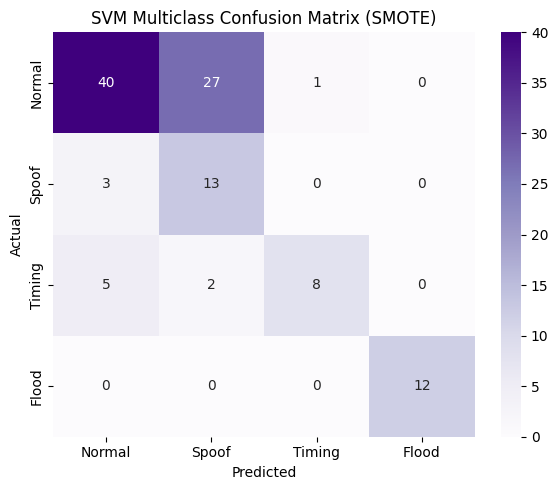

In [21]:
# Original
cm_svm_multi = confusion_matrix(y_test_m, svm_multi_pred)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm_svm_multi,
    annot=True,
    fmt="d",
    cmap="Purples",
    xticklabels=labels,
    yticklabels=labels
)

plt.title("SVM Multiclass Confusion Matrix (Original)")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.tight_layout()

# Save figure
plt.savefig("../results/confusion_matrices/svm_multiclass_original.png", dpi=300)

plt.show()

#SMOTE
cm_svm_multi_smote = confusion_matrix(y_test_m, svm_multi_pred_smote)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm_svm_multi_smote,
    annot=True,
    fmt="d",
    cmap="Purples",
    xticklabels=labels,
    yticklabels=labels
)

plt.title("SVM Multiclass Confusion Matrix (SMOTE)")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.tight_layout()

# Save figure
plt.savefig("../results/confusion_matrices/svm_multiclass_smote.png", dpi=300)

plt.show()

## Model Performance Comparison

This table presents the performance of the evaluated machine learning models across both binary and multiclass classification tasks.

The models included are Random Forest and Support Vector Machine (SVM), each trained and tested under two conditions:

- **Original Dataset**: The imbalanced dataset reflecting the natural distribution of network traffic.
- **SMOTE Dataset**: The training data balanced using Synthetic Minority Oversampling Technique (SMOTE).

Performance is measured using the following metrics:

- **Accuracy**: The overall proportion of correctly classified instances.
- **Precision**: The proportion of correctly predicted positive instances.
- **Recall**: The proportion of actual positive instances correctly identified.
- **F1-score**: The harmonic mean of precision and recall.

The table enables direct comparison of model performance across different tasks and dataset conditions.

In [22]:
# Random Forest (Binary)
rf_binary_report = classification_report(
    y_test, rf_pred, output_dict=True
)

rf_binary_smote_report = classification_report(
    y_test, rf_pred_smote, output_dict=True
)

# SVM (Binary)
svm_binary_report = classification_report(
    y_test, svm_pred, zero_division=0, output_dict=True
)

svm_binary_smote_report = classification_report(
    y_test, svm_pred_smote, zero_division=0, output_dict=True
)


# Random Forest (Multiclass)
rf_multi_report = classification_report(
    y_test_m, rf_multi_pred, output_dict=True
)

rf_multi_smote_report = classification_report(
    y_test_m, rf_multi_pred_smote, output_dict=True
)

# SVM (Multiclass)
svm_multi_report = classification_report(
    y_test_m, svm_multi_pred, zero_division=0, output_dict=True
)

svm_multi_smote_report = classification_report(
    y_test_m, svm_multi_pred_smote, zero_division=0, output_dict=True
)

In [23]:
summary = pd.DataFrame([

    # BINARY
    ["RF", "Binary", "Original",
     rf_binary_report["accuracy"],
     rf_binary_report["weighted avg"]["precision"],
     rf_binary_report["weighted avg"]["recall"],
     rf_binary_report["weighted avg"]["f1-score"]],

    ["RF", "Binary", "SMOTE",
     rf_binary_smote_report["accuracy"],
     rf_binary_smote_report["weighted avg"]["precision"],
     rf_binary_smote_report["weighted avg"]["recall"],
     rf_binary_smote_report["weighted avg"]["f1-score"]],

    ["SVM", "Binary", "Original",
     svm_binary_report["accuracy"],
     svm_binary_report["weighted avg"]["precision"],
     svm_binary_report["weighted avg"]["recall"],
     svm_binary_report["weighted avg"]["f1-score"]],

    ["SVM", "Binary", "SMOTE",
     svm_binary_smote_report["accuracy"],
     svm_binary_smote_report["weighted avg"]["precision"],
     svm_binary_smote_report["weighted avg"]["recall"],
     svm_binary_smote_report["weighted avg"]["f1-score"]],

    # MULTICLASS
    ["RF", "Multiclass", "Original",
     rf_multi_report["accuracy"],
     rf_multi_report["weighted avg"]["precision"],
     rf_multi_report["weighted avg"]["recall"],
     rf_multi_report["weighted avg"]["f1-score"]],

    ["RF", "Multiclass", "SMOTE",
     rf_multi_smote_report["accuracy"],
     rf_multi_smote_report["weighted avg"]["precision"],
     rf_multi_smote_report["weighted avg"]["recall"],
     rf_multi_smote_report["weighted avg"]["f1-score"]],

    ["SVM", "Multiclass", "Original",
     svm_multi_report["accuracy"],
     svm_multi_report["weighted avg"]["precision"],
     svm_multi_report["weighted avg"]["recall"],
     svm_multi_report["weighted avg"]["f1-score"]],

    ["SVM", "Multiclass", "SMOTE",
     svm_multi_smote_report["accuracy"],
     svm_multi_smote_report["weighted avg"]["precision"],
     svm_multi_smote_report["weighted avg"]["recall"],
     svm_multi_smote_report["weighted avg"]["f1-score"]],

], columns=[
    "Model", "Task", "Dataset",
    "Accuracy", "Precision", "Recall", "F1-score"
])

# Round values
summary = summary.round(3)

# Sort for readability
summary = summary.sort_values(by=["Task", "Model", "Dataset"]).reset_index(drop=True)

# Display
display(summary.style.background_gradient(cmap="Blues"))

# Save
summary.to_csv("../results/model_comparison_full.csv", index=False)

,Model,Task,Dataset,Accuracy,Precision,Recall,F1-score
0,RF,Binary,Original,0.883000,0.884000,0.883000,0.881000
1,RF,Binary,SMOTE,0.874000,0.873000,0.874000,0.873000
2,SVM,Binary,Original,0.757000,0.826000,0.757000,0.721000
3,SVM,Binary,SMOTE,0.838000,0.872000,0.838000,0.826000
4,RF,Multiclass,Original,0.856000,0.851000,0.856000,0.841000
5,RF,Multiclass,SMOTE,0.856000,0.857000,0.856000,0.853000
6,SVM,Multiclass,Original,0.766000,0.670000,0.766000,0.695000
7,SVM,Multiclass,SMOTE,0.658000,0.783000,0.658000,0.685000


### SMOTE Comparison Table (Original vs SMOTE side-by-side)

In [24]:
# reshape summary table into long format
melted = summary.melt(
    id_vars=["Model", "Task", "Dataset"],
    value_vars=["Accuracy", "Precision", "Recall", "F1-score"],
    var_name="Metric",
    value_name="Value"
)

# pivot so Original and SMOTE become columns
comparison = melted.pivot_table(
    index=["Model", "Task", "Metric"],
    columns="Dataset",
    values="Value"
).reset_index()

# clean column names
comparison.columns.name = None

# round values for readability
comparison = comparison.round(3)

# function to highlight better (green) and worse (red)
def highlight_better_worse(row):
    styles = [''] * len(row)

    original_idx = row.index.get_loc("Original")
    smote_idx = row.index.get_loc("SMOTE")

    if row["SMOTE"] > row["Original"]:
        styles[smote_idx] = "background-color: lightgreen"
        styles[original_idx] = "background-color: lightcoral"
    elif row["SMOTE"] < row["Original"]:
        styles[original_idx] = "background-color: lightgreen"
        styles[smote_idx] = "background-color: lightcoral"

    return styles

# apply styling
styled_table = comparison.style.apply(
    highlight_better_worse,
    axis=1
).format({
    "Original": "{:.3f}",
    "SMOTE": "{:.3f}"
})

# display styled table
display(styled_table)

# save table as CSV
comparison.to_csv("../results/model_comparison_smote.csv", index=False)

,Model,Task,Metric,Original,SMOTE
0,RF,Binary,Accuracy,0.883,0.874
1,RF,Binary,F1-score,0.881,0.873
2,RF,Binary,Precision,0.884,0.873
3,RF,Binary,Recall,0.883,0.874
4,RF,Multiclass,Accuracy,0.856,0.856
5,RF,Multiclass,F1-score,0.841,0.853
6,RF,Multiclass,Precision,0.851,0.857
7,RF,Multiclass,Recall,0.856,0.856
8,SVM,Binary,Accuracy,0.757,0.838
9,SVM,Binary,F1-score,0.721,0.826


### Feature Importance Analysis

This figure presents the feature importance scores derived from the Random Forest model. Feature importance indicates the relative contribution of each feature to the model’s classification decisions.

The features shown represent flow-level characteristics extracted from network traffic, including packet volume, timing behaviour, and transmission rate.

Higher importance scores indicate that a feature has a greater influence on the model’s decision-making process. Lower scores indicate reduced contribution.

The features included in this analysis are:

- **Packet-based metrics** (e.g., packet count, average packet size)
- **Traffic volume metrics** (e.g., total bytes)
- **Timing-based metrics** (e.g., interarrival mean, interarrival standard deviation)
- **Rate-based metrics** (e.g., packet rate, log-transformed packet rate)

This figure provides an overview of how different traffic characteristics contribute to classification within the Random Forest model.

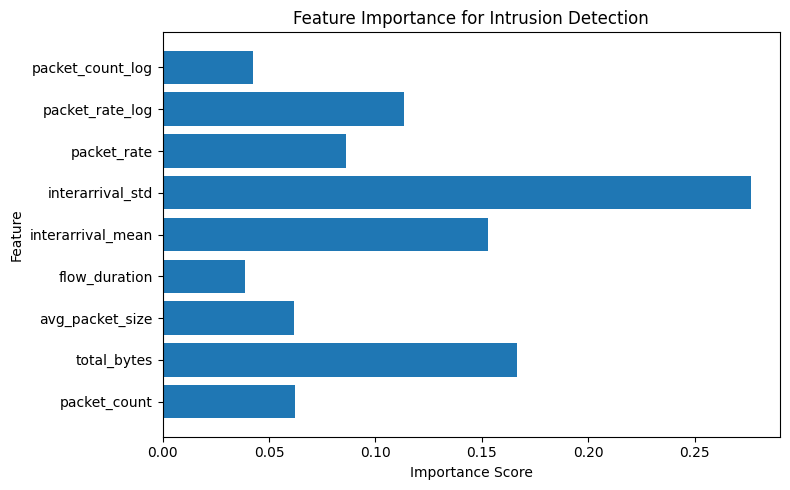

In [32]:
importance = rf_model.feature_importances_

# Create a bar chart to visualise feature importance
plt.figure(figsize=(8,5))

# Plot features against their importance scores
plt.barh(features, importance)

# Add title and axis labels
plt.title("Feature Importance for Intrusion Detection")
plt.xlabel("Importance Score")
plt.ylabel("Feature")

# Adjust layout to prevent label overlap
plt.tight_layout()

# Save figure
plt.savefig("../results/figures/feature_importance.png", dpi=300, bbox_inches='tight')

# Display
plt.show()

### SHAP Feature Contribution Analysis

This figure presents SHAP (SHapley Additive exPlanations) values for the Random Forest model. SHAP values provide a measure of how individual features contribute to model predictions for each instance in the dataset.

Each point in the plot represents a single flow observation. The position along the horizontal axis indicates the impact of a feature on the model output, while colour represents the relative value of the feature.

Features are ordered by their overall influence on model predictions, with the most influential features displayed at the top.

The SHAP values shown correspond to the classification of network traffic into normal and anomalous behaviour, based on the extracted flow-level features.

This figure provides a detailed view of how feature values contribute to classification decisions across the dataset.

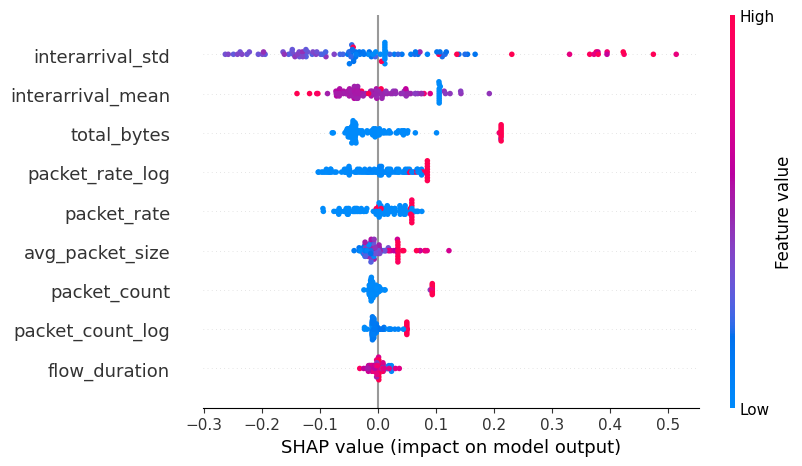

In [34]:
# Ensure test data uses the same features as the trained model
X_test_shap = X_test[rf_model.feature_names_in_]

# Create SHAP explainer for the Random Forest model
explainer = shap.Explainer(rf_model, X_test_shap)

# Compute SHAP values (disables strict additivity check to avoid errors)
shap_values = explainer(X_test_shap, check_additivity=False)

# Visualise feature contributions for class 1 (attack class)
shap.plots.beeswarm(shap_values[:, :, 1], show=False)

# Save figure
plt.savefig('../results/figures/shap_summary.png', dpi=300, bbox_inches='tight')

# Display
plt.show()

## Save All Trained Models

In [27]:

# RANDOM FOREST (BINARY)

joblib.dump(rf_model, "../results/trained_models/rf_binary_original.pkl")
joblib.dump(rf_model_smote, "../results/trained_models/rf_binary_smote.pkl")

# SVM (BINARY)

joblib.dump(svm_model, "../results/trained_models/svm_binary_original.pkl")
joblib.dump(svm_model_smote, "../results/trained_models/svm_binary_smote.pkl")

# Save scalers (SVM)
joblib.dump(scaler, "../results/trained_models/scaler_binary_original.pkl")
joblib.dump(scaler_smote, "../results/trained_models/scaler_binary_smote.pkl")

# RANDOM FOREST (MULTICLASS)

joblib.dump(rf_multi, "../results/trained_models/rf_multiclass_original.pkl")
joblib.dump(rf_multi_smote, "../results/trained_models/rf_multiclass_smote.pkl")

# SVM (MULTICLASS)

joblib.dump(svm_multi, "../results/trained_models/svm_multiclass_original.pkl")
joblib.dump(svm_multi_smote, "../results/trained_models/svm_multiclass_smote.pkl")

# Save scalers (SVM)
joblib.dump(scaler_m, "../results/trained_models/scaler_multiclass_original.pkl")
joblib.dump(scaler_m_smote, "../results/trained_models/scaler_multiclass_smote.pkl")


print("All models and scalers saved successfully.")

All models and scalers saved successfully.
